Imports, dfs

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

meta_raw = pd.read_csv("./data/metadata.csv")
meta = pd.read_csv("./data/new_metadata.csv")
meta = meta[meta["Valid_mask"] == True]

#run feature ext optimised and use current csv here
features = pd.read_csv("src/featureDf_17052026_changed.csv")



FileNotFoundError: [Errno 2] No such file or directory: 'src/featureDf_17052026_changed.csv'

# 1. Dataset statistics

In [ ]:
#number of images
print(f"Original metadata size: {meta_raw.shape} with {meta_raw.shape[0]} images")
print(f"Filtered metadata shape: {meta.shape} with {meta.shape[0]} images \n")

#number of patients

num_unique_patients = meta["patient_id"].nunique()
print(f"{meta.shape[0]} images apply to {num_unique_patients} unique patients, meaning there may be multiple lesion images per patient \n")

#count benign/malignant
#benign (OK)
#malignant (NOT OK)

benign_labels = ["ACK", "NEV", "SEK"]
benign_mask = meta["diagnostic"].isin(benign_labels)

benign = meta[benign_mask]

malignant_labels = ["BCC", "MEL", "SCC"]
malignant_mask = meta["diagnostic"].isin(malignant_labels)
malignant = meta[malignant_mask]

print(f"Benign diagnosises: {benign.shape[0]}")
print(f"Malignant diagnosises: {malignant.shape[0]}")

Original metadata size: (2298, 26) with 2298 images
Filtered metadata shape: (1945, 6) with 1945 images 

1945 images apply to 1223 unique patients, meaning there may be multiple lesion images per patient 

Benign diagnosises: 925
Malignant diagnosises: 1020


## Investigate class inbalance

In [ ]:
#percentage distribution

total = len(meta)

benign_p = benign.shape[0] / total * 100
malignant_p = malignant.shape[0] / total * 100

print(f"Benign: {benign_p:.2f}%")
print(f"Malignant: {malignant_p:.2f}%")


display(meta["diagnostic"].value_counts())

display(meta["diagnostic"].value_counts(normalize=True) * 100)

Benign: 47.56%
Malignant: 52.44%


diagnostic
BCC    793
ACK    535
NEV    210
SEK    180
SCC    179
MEL     48
Name: count, dtype: int64

diagnostic
BCC    40.771208
ACK    27.506427
NEV    10.796915
SEK     9.254499
SCC     9.203085
MEL     2.467866
Name: proportion, dtype: float64

40% of the WHOLE dataset is BCC


The overall proportion of benign & malignant is a bit imbalanced (48% / 52%), which is an acceptable imbalance.

However, BCC takes over the 40% of the WEHOLE DATASET.

So the model may:
- learn BCC patterns well,
- struggle with melanoma bc melanoma is clinically important

So even though the binary classification is balanced, the diagnostic sybtype distribution is highly uneven

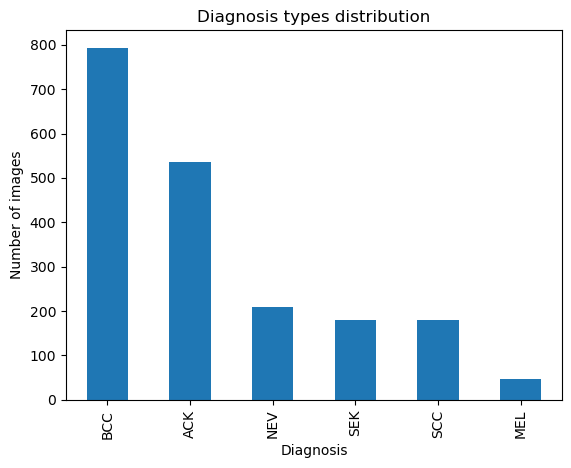

In [ ]:
#Barplot of diagnosises

meta["diagnostic"].value_counts().plot(kind="bar")

plt.xlabel("Diagnosis")
plt.ylabel("Number of images")
plt.title("Diagnosis types distribution")

plt.show()
#prob should save it later

## Check for patient imbalance 

Some patients can have more images of lesions

count    1223.000000
mean        1.590352
std         1.011297
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        10.000000
Name: count, dtype: float64

Most patients have only one image, however a minority still has multiple lesion images.


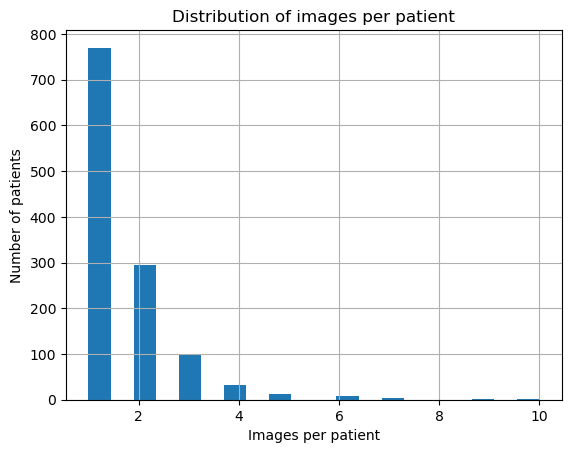

In [ ]:
patient_counts = meta["patient_id"].value_counts()

display(patient_counts.describe())
print("Most patients have only one image, however a minority still has multiple lesion images.")

#visualize
patient_counts.hist(bins=20)

plt.xlabel("Images per patient")
plt.ylabel("Number of patients")
plt.title("Distribution of images per patient")

plt.show()
#if used in a report, save this one too

# 2. Feature statistics

Quality control

In [ ]:
#missing values
display(features.isna().sum())

display((features.isna().mean() * 100).sort_values(ascending=False))



img_id                  0
hsv_mean_h              0
hsv_mean_s              0
hsv_mean_v              0
hsv_std_h               0
hsv_std_s               0
hsv_std_v               0
sp_hsv_std_h            2
sp_hsv_std_s            2
sp_hsv_std_v            2
rel_hsv_diff_h          0
rel_hsv_diff_s          0
rel_hsv_diff_v          0
symmetry                0
border                  0
diameter                0
processing_status       0
error_message        1945
dtype: int64

error_message        100.000000
sp_hsv_std_s           0.102828
sp_hsv_std_h           0.102828
sp_hsv_std_v           0.102828
hsv_mean_h             0.000000
img_id                 0.000000
hsv_std_s              0.000000
hsv_std_h              0.000000
hsv_mean_v             0.000000
hsv_mean_s             0.000000
hsv_std_v              0.000000
rel_hsv_diff_h         0.000000
rel_hsv_diff_v         0.000000
rel_hsv_diff_s         0.000000
symmetry               0.000000
border                 0.000000
diameter               0.000000
processing_status      0.000000
dtype: float64

## Investigate NaN values

Check whether the reason os the diameter size - the lesion is too small

In [ ]:
failed = features[features["sp_hsv_std_h"].isna()]
working = features[~features["sp_hsv_std_h"].isna()]

print("Failed mean diameter:", failed["diameter"].mean())
print("Working mean diameter:", working["diameter"].mean())


Failed mean diameter: 1.0
Working mean diameter: 0.9677305914739595


### Since the percentage for each is ~1.8%, we could still accept it and deal with them the following way:

#### The SLIC-based local color features produced missing values in approximately 1.8% of lesions, likely due to unstable or insufficient superpixel segmentation in certain cases.

check whether they fail for the same images

In [ ]:
failed_rows = features[features["sp_hsv_std_h"].isna()]

display(failed_rows[["img_id", "diameter"]].describe())
failed_rows[["img_id", "diameter"]].head()

,diameter
count,2.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


,img_id,diameter
51,PAT_868_1657_698.png,1.0
511,PAT_753_1428_451.png,1.0


#### We can leave it as it is and mention it in the report.

However, we should handle this in our modelling buildings!

It is currently handled like this:  X = df[feature_cols].fillna(0) 
So, the Nan becomes 0. Its kinda fine, but  we should precisely explain ot in hte report because 0 could look like a real value.


### Descriptive stats, unique values

In [ ]:
features.nunique()
features.describe()

,hsv_mean_h,hsv_mean_s,hsv_mean_v,hsv_std_h,hsv_std_s,hsv_std_v,sp_hsv_std_h,sp_hsv_std_s,sp_hsv_std_v,rel_hsv_diff_h,rel_hsv_diff_s,rel_hsv_diff_v,symmetry,border,diameter,error_message
count,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1943.000000,1943.000000,1943.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,0.0
mean,0.644954,0.355895,0.613571,0.043957,0.089710,0.077557,0.037375,0.080596,0.069810,0.029571,0.064028,0.060040,0.778159,0.728813,0.967764,NaN
std,0.076827,0.144611,0.134437,0.061320,0.036872,0.034440,0.057029,0.033968,0.034353,0.053008,0.057688,0.062803,0.122318,0.138394,0.057472,NaN
min,0.016697,0.049125,0.141581,0.003344,0.017332,0.011323,0.002128,0.014438,0.010708,0.000001,0.000012,0.000083,0.094436,0.073791,0.308594,NaN
25%,0.620563,0.246343,0.530863,0.011953,0.061993,0.051825,0.010102,0.055164,0.043273,0.006981,0.020632,0.015996,0.718943,0.665462,0.960938,NaN
50%,0.644776,0.348380,0.611648,0.018885,0.084622,0.071425,0.015932,0.075483,0.063432,0.014669,0.050165,0.036946,0.801398,0.771066,0.992188,NaN
75%,0.670404,0.455681,0.703438,0.043101,0.109922,0.097381,0.034620,0.099010,0.089756,0.030162,0.090548,0.082511,0.869088,0.831661,1.000000,NaN
max,0.966211,0.803828,0.984125,0.384439,0.283847,0.251288,0.382560,0.283817,0.236474,0.488991,0.431017,0.378926,0.980395,0.904025,1.000000,NaN


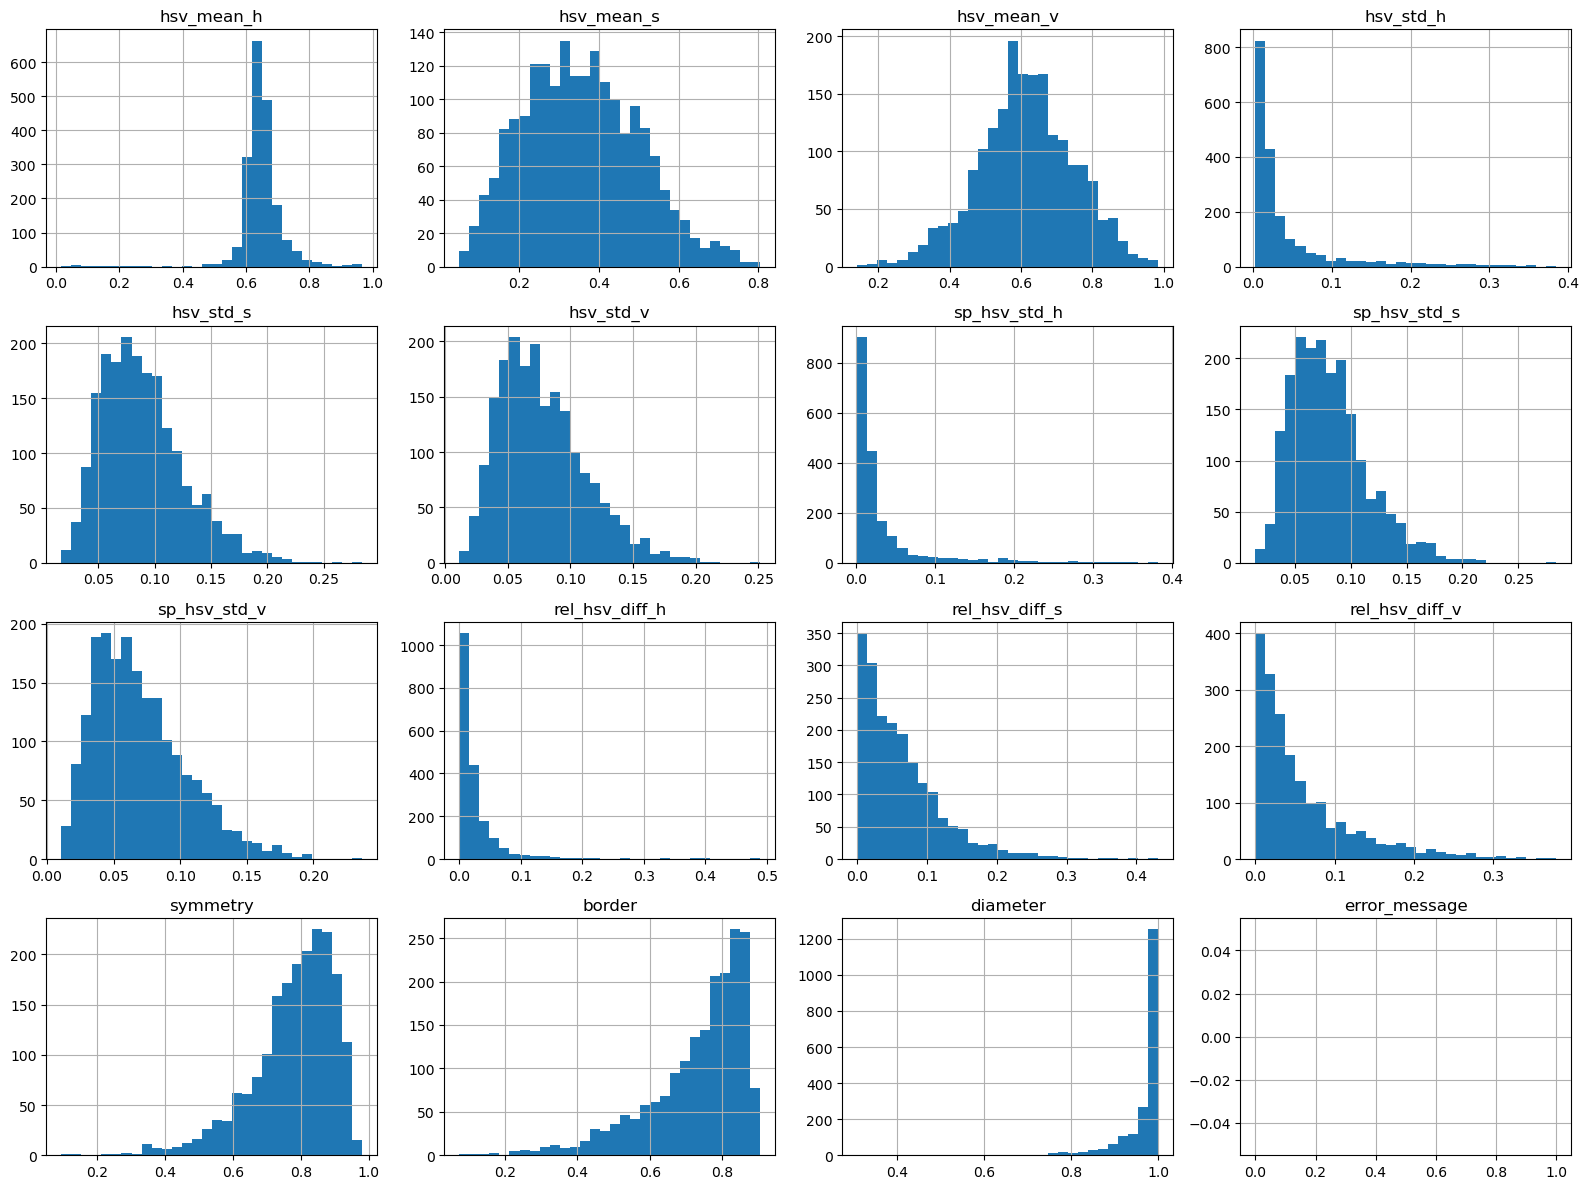

In [ ]:
numeric_cols = features.select_dtypes(include=np.number).columns

features[numeric_cols].hist(figsize=(16,12), bins=30)

plt.tight_layout()
plt.show()

Check notebook to see small comments

C:\Users\zinov\AppData\Local\Temp\ipykernel_25752\3768860720.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


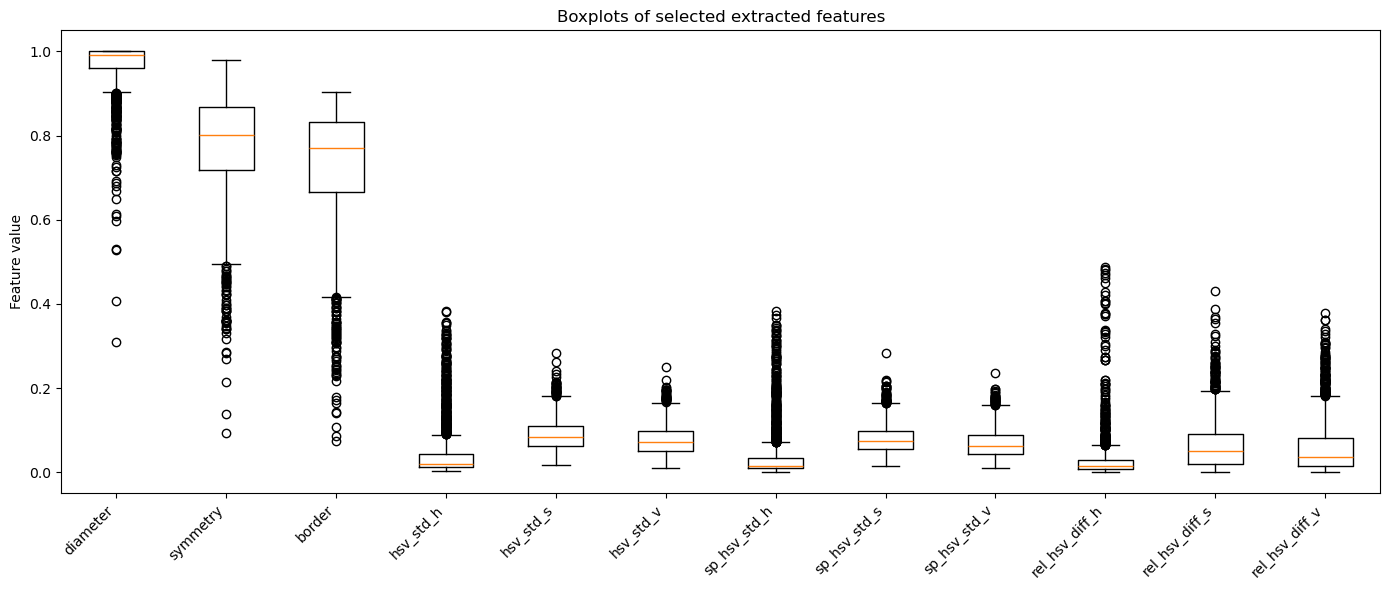

In [ ]:
boxplot_cols = [
    "diameter", "symmetry", "border",
    "hsv_std_h", "hsv_std_s", "hsv_std_v",
    "sp_hsv_std_h", "sp_hsv_std_s", "sp_hsv_std_v",
    "rel_hsv_diff_h", "rel_hsv_diff_s", "rel_hsv_diff_v"
]

# keep only columns that exist
boxplot_cols = [col for col in boxplot_cols if col in features.columns]

plt.figure(figsize=(14, 6))
plt.boxplot(
    [features[col].dropna() for col in boxplot_cols],
    labels=boxplot_cols,
    showfliers=True
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Feature value")
plt.title("Boxplots of selected extracted features")
plt.tight_layout()
plt.show()

Check notebook for comments

## Correlation matrix

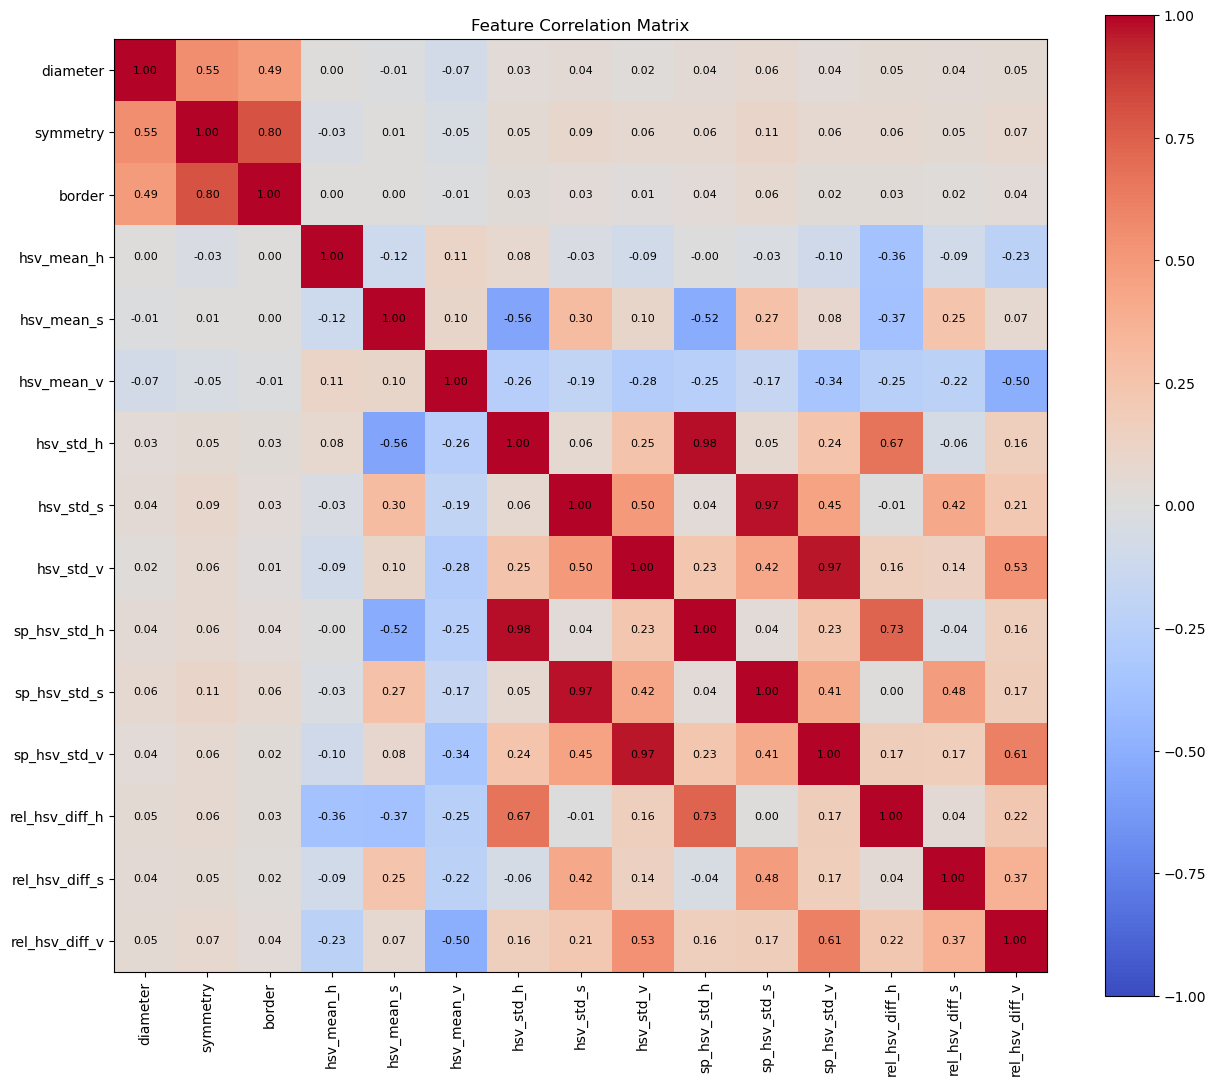

In [ ]:
feature_cols = [
    "diameter",
    "symmetry",
    "border",
    "hsv_mean_h",
    "hsv_mean_s",
    "hsv_mean_v",
    "hsv_std_h",
    "hsv_std_s",
    "hsv_std_v",
    "sp_hsv_std_h",
    "sp_hsv_std_s",
    "sp_hsv_std_v",
    "rel_hsv_diff_h",
    "rel_hsv_diff_s",
    "rel_hsv_diff_v"
]
#drop NaN rows
corr_df = features[feature_cols].dropna()

corr = corr_df.corr()

#plot corr
plt.figure(figsize=(13, 11))

im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im)

plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)

# add numbers
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        value = corr.iloc[i, j]
        plt.text(
            j, i, f"{value:.2f}",
            ha="center", va="center",
            fontsize=8
        )

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Evaluation: Comparing 3 Models

Compare **kNN**, **Logistic Regression**, and **Decision Tree** on the held-out test set.

All three models share the same patient-level train/test split (`random_state=42`), so their predictions on the test set are directly comparable.

## Imports

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve

FIG_DIR = './results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Load predictions from all 3 models

Each CSV has columns: `patient_id, img_id, diagnostic, label, predicted, probability`.

- `label` — true class (0 = benign, 1 = cancer)
- `predicted` — model's hard prediction (0 or 1)
- `probability` — model's probability that the lesion is cancer

In [ ]:
pred_dt  = pd.read_csv('./results/predictions/predictions_DT.csv')
pred_knn = pd.read_csv('./results/predictions/predictions_kNN.csv')
pred_lr  = pd.read_csv('./results/predictions/predictions_LR.csv')

models = {
    'kNN':                 pred_knn,
    'Logistic Regression': pred_lr,
    'Decision Tree':       pred_dt,
}

# Sanity check: same test set across models?
for name, df in models.items():
    pos = int(df['label'].sum())
    print(f'{name:22s} | n = {len(df):4d} | positives = {pos:3d} ({100*pos/len(df):.1f}%)')

kNN                    | n =  404 | positives = 222 (55.0%)
Logistic Regression    | n =  404 | positives = 222 (55.0%)
Decision Tree          | n =  404 | positives = 222 (55.0%)


## 2. Metrics table

One table summarising the five most important metrics for all three models.

- **Accuracy** - share of correct predictions (can be misleading with class imbalance)
- **Precision** - of predicted cancers, how many were actually cancer (low false alarms)
- **Recall (Sensitivity)** - of actual cancers, how many we caught (low missed cancers)
- **F1** - harmonic mean of precision and recall
- **AUC** - probability that a random cancer lesion gets a higher score than a random benign one

In [ ]:
def compute_metrics(df):
    y_true = df['label']
    y_pred = df['predicted']
    y_prob = df['probability']
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'AUC':       roc_auc_score(y_true, y_prob),
    }

metrics_table = pd.DataFrame(
    {name: compute_metrics(df) for name, df in models.items()}
).T

metrics_table.round(3)

,Accuracy,Precision,Recall,F1,AUC
kNN,0.705,0.754,0.689,0.720,0.777
Logistic Regression,0.693,0.750,0.662,0.703,0.767
Decision Tree,0.673,0.705,0.698,0.701,0.711


In [ ]:
# Save metrics table to CSV for the report
os.makedirs('./results/reports', exist_ok=True)
metrics_table.round(4).to_csv('./results/reports/metrics_comparison.csv')
print('Saved to ./results/reports/metrics_comparison.csv')

Saved to ./results/reports/metrics_comparison.csv


## 3. ROC curves

ROC plots the trade-off between **True Positive Rate** (catching cancer) and **False Positive Rate** (false alarms) as we slide the decision threshold from 0 to 1.

- Curve closer to the top-left corner = better model
- The diagonal dashed line = random guessing (AUC = 0.5)

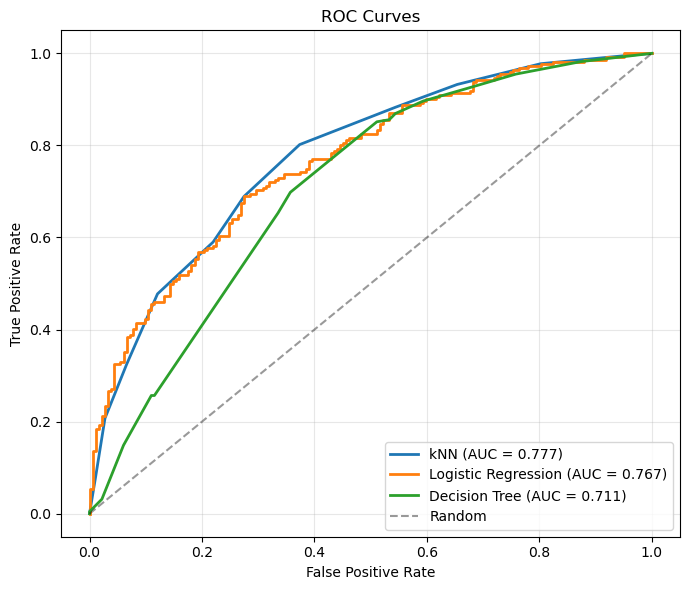

In [ ]:
plt.figure(figsize=(7, 6))

for name, df in models.items():
    fpr, tpr, _ = roc_curve(df['label'], df['probability'])
    auc = roc_auc_score(df['label'], df['probability'])
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/roc_curves.png', dpi=150)
plt.show()

## 4. Confusion matrices

Each cell shows how many test images fell into one of four buckets:

|                  | Predicted Benign | Predicted Cancer |
|------------------|------------------|------------------|
| **Actual Benign**| True Negative    | False Positive (false alarm) |
| **Actual Cancer**| **False Negative (missed cancer)** | True Positive |

 **False Negatives are the worst** bc that would mean we sent a cancer patient home

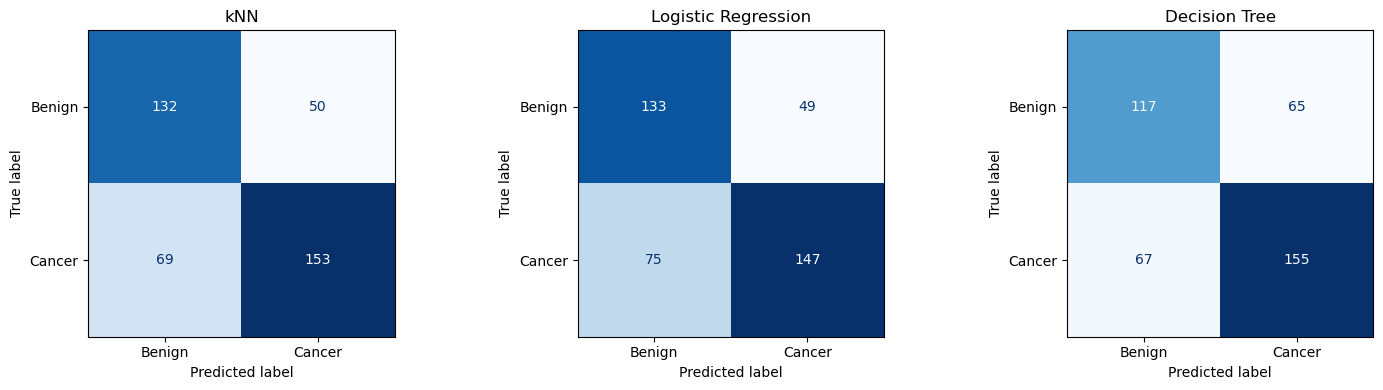

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes, models.items()):
    cm = confusion_matrix(df['label'], df['predicted'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Cancer'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/confusion_matrices.png', dpi=150)
plt.show()

## 5. Calibration plots

A model can be **accurate but poorly calibrated**: it ranks cases correctly, but its probabilities don't match real frequencies.

If the model says "80% chance of cancer" for 100 lesions, we'd expect ~80 of them to actually be cancer. The calibration curve plots:
- **x-axis**: average predicted probability in each bin
- **y-axis**: actual fraction of cancer cases in that bin

Closer to the diagonal = better calibrated.

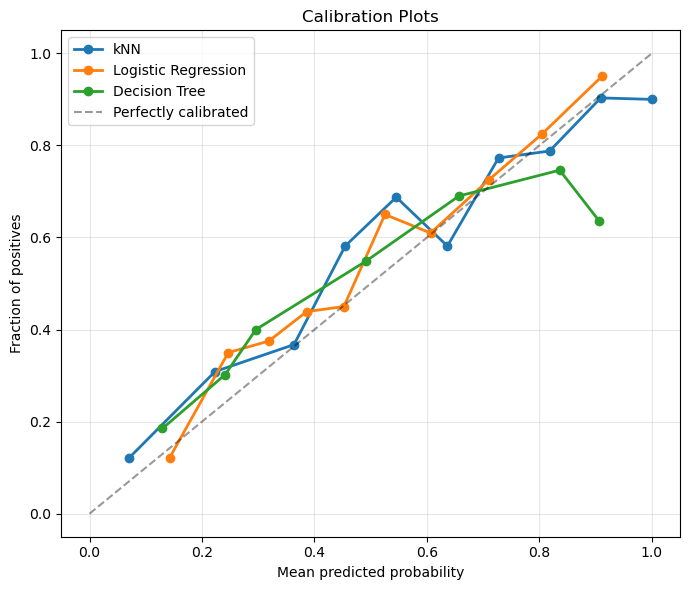

In [ ]:
plt.figure(figsize=(7, 6))

for name, df in models.items():
    frac_pos, mean_pred = calibration_curve(df['label'], df['probability'], n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', lw=2, label=name)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Plots')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/calibration.png', dpi=150)
plt.show()

## 6. Class balance in the test set

Quick sanity check on how imbalanced the test set is - this affects how we interpret the metrics above.

In [ ]:
any_df = next(iter(models.values()))
n = len(any_df)
n_pos = int(any_df['label'].sum())
n_neg = n - n_pos

print(f'Test set size: {n}')
print(f'  Benign (0):  {n_neg} ({100*n_neg/n:.1f}%)')
print(f'  Cancer (1):  {n_pos} ({100*n_pos/n:.1f}%)')
print(f'Baseline accuracy (predict majority class): {max(n_pos, n_neg) / n:.3f}')

Test set size: 404
  Benign (0):  182 (45.0%)
  Cancer (1):  222 (55.0%)
Baseline accuracy (predict majority class): 0.550


## 7. Confidence intervals for AUC (Bootstrap)

The AUC numbers above are **point estimates** - single numbers computed on **this specific test set**. With a different test set we would get slightly different AUCs.

**Bootstrap** answers: *how stable is this AUC?* The recipe is:

1. Randomly resample the test set **with replacement** (same size, but some patients appear twice, some are missing).
2. Compute AUC on this resample.
3. Repeat 1000 times -> distribution of plausible AUC values.
4. The **2.5th** and **97.5th percentiles** give a **95% confidence interval**.

**How to interpret**:
- A narrow CI (e.g., 0.82–0.85) -> AUC is stable, we trust the number.
- A wide CI (e.g., 0.65–0.90) -> AUC is noisy, the test set is too small to be confident.
- If two models' CIs **don't overlap** -> strong evidence one is genuinely better.

In [ ]:
def bootstrap_auc_ci(df, n_iter=1000, seed=42):
    rng = np.random.RandomState(seed)
    y_true = df['label'].values
    y_prob = df['probability'].values
    n = len(df)
    aucs = []
    for _ in range(n_iter):
        idx = rng.randint(0, n, n)
        # Skip resamples that lost one of the classes (AUC undefined)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    aucs = np.array(aucs)
    return {
        'AUC (mean)': aucs.mean(),
        'CI lower':   np.percentile(aucs, 2.5),
        'CI upper':   np.percentile(aucs, 97.5),
    }

ci_table = pd.DataFrame({name: bootstrap_auc_ci(df) for name, df in models.items()}).T
ci_table['CI width'] = ci_table['CI upper'] - ci_table['CI lower']
ci_table.round(3)

,AUC (mean),CI lower,CI upper,CI width
kNN,0.779,0.731,0.822,0.091
Logistic Regression,0.769,0.723,0.811,0.088
Decision Tree,0.711,0.662,0.756,0.094


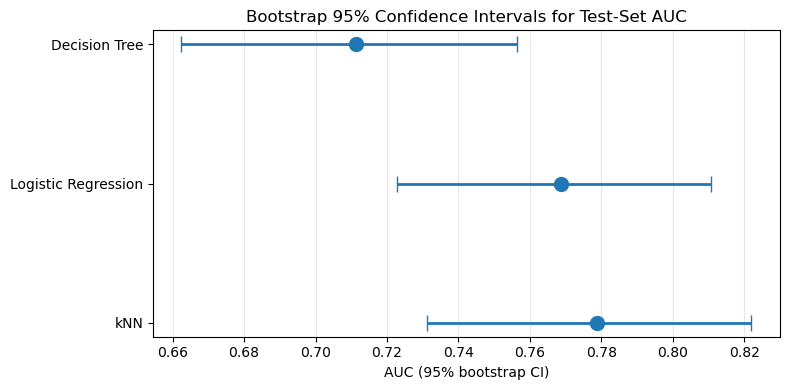

In [ ]:
# Visualise CIs as error bars - easier to spot overlap between models
fig, ax = plt.subplots(figsize=(8, 4))
y_pos = np.arange(len(ci_table))
ax.errorbar(
    ci_table['AUC (mean)'], y_pos,
    xerr=[ci_table['AUC (mean)'] - ci_table['CI lower'],
          ci_table['CI upper'] - ci_table['AUC (mean)']],
    fmt='o', capsize=6, markersize=10, lw=2,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(ci_table.index)
ax.set_xlabel('AUC (95% bootstrap CI)')
ax.set_title('Bootstrap 95% Confidence Intervals for Test-Set AUC')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/auc_ci.png', dpi=150)
plt.show()

## 8. Statistical significance: are the models really different?

Bootstrap CIs above describe **one model at a time**. To compare **two models head-to-head** (e.g., "is kNN significantly better than Decision Tree?"), we use the **per-fold AUC scores from cross-validation**.

Each model produces 5 numbers (one per fold). Because all 3 models use the **same folds**, the scores are **paired** - we can subtract them fold-by-fold and ask whether the differences are systematically positive/negative or just noise.

- **Wilcoxon signed-rank test** - non-parametric, works on the ranks of differences. Preferred with only 5 folds because we can't reliably check normality.
- **Paired t-test** - parametric alternative.
- **Null hypothesis (H0)**: the two models perform equally well.
- **p-value < 0.05** -> reject H0 -> models differ significantly.

**Important caveat**: with only **5 folds**, statistical power is low. A non-significant result (p > 0.05) does **not** mean the models are equally good - it might just mean we don't have enough data to detect the difference.

**This cell requires** that the three model scripts have been re-run with the updated code that saves `cv_folds_*.csv` files.

In [3]:
try:
    cv_dt  = pd.read_csv('./results/predictions/cv_folds_DT.csv')
    cv_knn = pd.read_csv('./results/predictions/cv_folds_kNN.csv')
    cv_lr  = pd.read_csv('./results/predictions/cv_folds_LR.csv')

    cv_results = pd.DataFrame({
        'kNN':                 cv_knn['auc'].values,
        'Logistic Regression': cv_lr['auc'].values,
        'Decision Tree':       cv_dt['auc'].values,
    })
    cv_results.index = [f'fold {i+1}' for i in range(len(cv_results))]
    print('Per-fold AUC scores (best hyperparameter for each model):')
    print(cv_results.round(3))
    print('\nMean AUC across folds:')
    print(cv_results.mean().round(3))
    print('\nStd of AUC across folds:')
    print(cv_results.std().round(3))
except FileNotFoundError as e:
    print(f'Missing CV results file: {e.filename}')
    print('Re-run Decision Tree.py, kNN.py, and the Logistic Regression script to generate them.')

Per-fold AUC scores (best hyperparameter for each model):
          kNN  Logistic Regression  Decision Tree
fold 1  0.722                0.791          0.720
fold 2  0.766                0.777          0.744
fold 3  0.722                0.686          0.671
fold 4  0.712                0.738          0.656
fold 5  0.737                0.738          0.674

Mean AUC across folds:
kNN                    0.732
Logistic Regression    0.746
Decision Tree          0.693
dtype: float64

Std of AUC across folds:
kNN                    0.021
Logistic Regression    0.041
Decision Tree          0.037
dtype: float64


In [4]:
from scipy.stats import wilcoxon, ttest_rel
from itertools import combinations

if 'cv_results' not in dir():
    print('cv_results is not defined — the previous cell could not load cv_folds_*.csv.')
    print('Re-run main.py, kNN.py, and the Logistic Regression script first, then run the cells again.')
else:
    rows = []
    for m1, m2 in combinations(cv_results.columns, 2):
        diff = cv_results[m1] - cv_results[m2]
        try:
            _, w_p = wilcoxon(diff)
        except ValueError:
            w_p = np.nan  # all-zero differences
        _, t_p = ttest_rel(cv_results[m1], cv_results[m2])
        rows.append({
            'Model A':           m1,
            'Model B':           m2,
            'Mean(A) - Mean(B)': diff.mean(),
            'Wilcoxon p':        w_p,
            'Paired t-test p':   t_p,
            'Significant (p<0.05, Wilcoxon)': bool(w_p < 0.05) if not np.isnan(w_p) else False,
        })
    display(pd.DataFrame(rows).round(4))

,Model A,Model B,Mean(A) - Mean(B),Wilcoxon p,Paired t-test p,"Significant (p<0.05, Wilcoxon)"
0,kNN,Logistic Regression,-0.0146,0.4375,0.4428,False
1,kNN,Decision Tree,0.0385,0.0625,0.0293,False
2,Logistic Regression,Decision Tree,0.0531,0.0625,0.0135,False


### How to read the table above

- **Mean(A) - Mean(B)** positive -> Model A has higher mean AUC than Model B across folds.
- **Wilcoxon p < 0.05** -> the difference is statistically significant.
- If both p-values agree -> strong signal.
- If Wilcoxon says yes but t-test says no -> trust Wilcoxon (fewer assumptions, more robust at n=5).

### What to write in the report

Combine three pieces of evidence:

1. **Point estimate**: "Model X achieved AUC = 0.85 on the held-out test set."
2. **Confidence interval**: "95% bootstrap CI: [0.81, 0.89]" - tells the reader how stable that number is.
3. **Pairwise comparison**: "Across 5 CV folds, kNN had significantly higher AUC than Decision Tree (Wilcoxon p = 0.03)."